<a href="https://colab.research.google.com/github/DhimanTarafdar/gallbladder_cancer_research/blob/main/Gallbladder_Cancer_Biomarker_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# STAGE 0: Setup
# ============================================================
!pip install rpy2 combat gseapy --quiet

import pandas as pd
import numpy as np
import re
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, r
from rpy2.robjects.packages import importr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter

robjects.r('''
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager", repos="http://cran.r-project.org")
BiocManager::install(c("limma", "edgeR"), update = FALSE, ask = FALSE)
''')
pandas2ri.activate()
print("Setup done")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 12.8 MB/s eta 0:00:00


(as ‘lib’ is unspecified)







	‘/tmp/RtmpwHDI7Z/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com











	‘/tmp/RtmpwHDI7Z/downloaded_packages’



Setup done


In [ ]:
# ============================================================
# STAGE 1: Load all 3 datasets and build clean labeled subsets
# (Same as before -- this part was already correct)
# ============================================================

# ---- GSE139682 ----
df_139682 = pd.read_csv('GSE139682_all.rpkm.txt', sep='\t')
normal_cols_139682 = [c for c in df_139682.columns if c.startswith('Normal')]
tumor_cols_139682  = [c for c in df_139682.columns if c.startswith('Tumor')]

# ---- GSE202479 (with ALL stage labels this time, not just advanced) ----
def extract_full_metadata_line(path, keyword):
    with open(path, 'r', errors='ignore') as f:
        for line in f:
            if line.startswith(keyword):
                parts = line.strip().split('\t')
                return [p.strip('"') for p in parts][1:]
    return None

titles = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_title')
tissue_type = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_characteristics_ch1')

stage_map_202479 = {}
for title, tissue in zip(titles, tissue_type):
    code = re.search(r'\[(.*?)\]', title).group(1)
    stage_map_202479[code] = tissue.replace('tissue type: ', '').strip()

# Discovery labels: normal vs advanced (used for training, same as before)
normal_codes = [c for c, s in stage_map_202479.items() if s == 'normal gallbladder']
advanced_codes = [c for c, s in stage_map_202479.items() if s == 'advanced gallbladder cancer']
# NEW: early-stage codes, kept SEPARATE, never used in training -- for a fair early-detection test
early_codes = [c for c, s in stage_map_202479.items() if s == 'early gallbladder cancer']

normal_cols_202479   = [f"{c}_count" for c in normal_codes]
tumor_cols_202479    = [f"{c}_count" for c in advanced_codes]
early_cols_202479    = [f"{c}_count" for c in early_codes]

df_202479 = pd.read_csv('GSE202479_gene_expression_anno.txt', sep='\t')  # use your actual filename

# ---- GSE132223 ----
df_13223 = pd.read_csv('GSE132223_norm_counts_TPM_GRCh38.p13_NCBI.tsv', sep='\t')  # use your actual filename
label_map_13223 = {
    'GSM3854440':'normal','GSM3854441':'tumor','GSM3854442':'exclude',
    'GSM3854443':'normal','GSM3854444':'tumor','GSM3854445':'exclude',
    'GSM3854446':'normal','GSM3854447':'tumor','GSM3854448':'exclude'
}
normal_samples_13223 = [k for k,v in label_map_13223.items() if v=='normal']
tumor_samples_13223  = [k for k,v in label_map_13223.items() if v=='tumor']

# ---- Annotation file (for ID mapping) ----
df_annot = pd.read_csv('Human.GRCh38.p13.annot.tsv', sep='\t', low_memory=False)
entrez_to_symbol = dict(zip(df_annot['GeneID'].astype(str), df_annot['Symbol']))
ensembl_to_symbol = dict(zip(df_annot['EnsemblGeneID'], df_annot['Symbol']))

print("All 3 datasets loaded.")
print(f"GSE139682: {len(normal_cols_139682)} normal, {len(tumor_cols_139682)} tumor")
print(f"GSE202479: {len(normal_cols_202479)} normal, {len(tumor_cols_202479)} advanced tumor, {len(early_cols_202479)} early tumor (held out)")
print(f"GSE13223: {len(normal_samples_13223)} normal, {len(tumor_samples_13223)} tumor")

All 3 datasets loaded.
GSE139682: 10 normal, 10 tumor
GSE202479: 3 normal, 5 advanced tumor, 5 early tumor (held out)
GSE13223: 3 normal, 3 tumor


In [ ]:
# ============================================================
# STAGE 2: DEG analysis (unchanged -- this step was already solid)
# ============================================================

def run_limma_normalized(expr_df, gene_col, normal_cols, tumor_cols, name="Dataset"):
    expr_matrix = np.log2(expr_df[normal_cols + tumor_cols].values + 1)
    genes = expr_df[gene_col].values.astype(str)
    n1, n2 = len(normal_cols), len(tumor_cols)
    r.assign('expr_mat', expr_matrix)
    r.assign('gene_ids', robjects.StrVector(genes))
    r(f'''
    library(limma)
    rownames(expr_mat) <- gene_ids
    group <- factor(c(rep("normal",{n1}), rep("tumor",{n2})), levels=c("normal","tumor"))
    design <- model.matrix(~group)
    fit <- eBayes(lmFit(expr_mat, design))
    result <- topTable(fit, coef=2, number=Inf, sort.by="P")
    ''')
    with (robjects.default_converter + pandas2ri.converter).context():
        result_df = robjects.conversion.get_conversion().rpy2py(r('result'))
    result_df.index.name = 'GeneID'
    return result_df.reset_index()

def run_limma_voom(count_df, gene_col, normal_cols, tumor_cols, name="Dataset"):
    count_matrix = count_df[normal_cols + tumor_cols].values
    genes = count_df[gene_col].values.astype(str)
    n1, n2 = len(normal_cols), len(tumor_cols)
    r.assign('count_mat', count_matrix)
    r.assign('gene_ids', robjects.StrVector(genes))
    r(f'''
    rownames(count_mat) <- gene_ids
    group <- factor(c(rep("normal",{n1}), rep("tumor",{n2})), levels=c("normal","tumor"))
    design <- model.matrix(~group)
    library(edgeR)
    dge <- DGEList(counts=count_mat)
    keep <- filterByExpr(dge, design)
    dge <- dge[keep,, keep.lib.sizes=FALSE]
    dge <- calcNormFactors(dge)
    v <- voom(dge, design)
    fit <- eBayes(lmFit(v, design))
    result <- topTable(fit, coef=2, number=Inf, sort.by="P")
    ''')
    with (robjects.default_converter + pandas2ri.converter).context():
        result_df = robjects.conversion.get_conversion().rpy2py(r('result'))
    result_df.index.name = 'GeneID'
    return result_df.reset_index()

deg_139682 = run_limma_normalized(df_139682, 'GeneID', normal_cols_139682, tumor_cols_139682)
deg_202479 = run_limma_voom(df_202479, 'gene_id', normal_cols_202479, tumor_cols_202479)

def filter_sig(deg_df, logfc_thresh=1, padj_thresh=0.05):
    return deg_df[(deg_df['adj.P.Val'] < padj_thresh) & (deg_df['logFC'].abs() > logfc_thresh)]

sig_139682 = filter_sig(deg_139682)
sig_202479 = filter_sig(deg_202479)

sig_139682_genes = set(sig_139682['GeneID'])
sig_202479_genes = set(sig_202479['GeneID'].map(ensembl_to_symbol).dropna())

consensus_genes = sorted(sig_139682_genes & sig_202479_genes)
print(f"Consensus DEG pool: {len(consensus_genes)} genes")

Consensus DEG pool: 178 genes


In [ ]:
# ============================================================
# STAGE 3: Build discovery expression matrix
# FIX for Issue #3: use per-dataset Z-score normalization (NOT ComBat),
# because ComBat mixing train+test caused leakage risk
# ============================================================

def zscore_per_dataset(expr_df):
    # standardize each gene (row) within this dataset only, no cross-dataset info used
    return expr_df.sub(expr_df.mean(axis=1), axis=0).div(expr_df.std(axis=1) + 1e-9, axis=0)

# GSE139682 expression for consensus genes
expr_139682 = df_139682[df_139682['GeneID'].isin(consensus_genes)].set_index('GeneID')
expr_139682 = expr_139682[normal_cols_139682 + tumor_cols_139682]
expr_139682 = np.log2(expr_139682 + 1)
expr_139682_z = zscore_per_dataset(expr_139682)

# GSE202479 expression for consensus genes (advanced tumor + normal, discovery set)
df_202479_annot = df_202479.copy()
df_202479_annot['Symbol'] = df_202479_annot['gene_id'].map(ensembl_to_symbol)
expr_202479 = df_202479_annot[df_202479_annot['Symbol'].isin(consensus_genes)].drop_duplicates(subset='Symbol')
expr_202479 = expr_202479.set_index('Symbol')[normal_cols_202479 + tumor_cols_202479]
expr_202479 = np.log2(expr_202479 + 1)
expr_202479_z = zscore_per_dataset(expr_202479)

# Keep only genes present in both
common_genes = sorted(set(expr_139682_z.index) & set(expr_202479_z.index))
expr_139682_z = expr_139682_z.loc[common_genes]
expr_202479_z = expr_202479_z.loc[common_genes]

# Combine into one discovery matrix: samples x genes
discovery_expr = pd.concat([expr_139682_z, expr_202479_z], axis=1).T
discovery_labels = (['normal']*len(normal_cols_139682) + ['tumor']*len(tumor_cols_139682) +
                     ['normal']*len(normal_cols_202479) + ['tumor']*len(tumor_cols_202479))

print(f"Discovery matrix: {discovery_expr.shape}, genes: {len(common_genes)}")

Discovery matrix: (28, 178), genes: 178


In [ ]:
# ============================================================
# STAGE 4: Nested Cross-Validation feature selection + evaluation
# FIX for Issue #1: this is now the ONLY feature selection method used.
# The final panel comes directly and traceably from this step.
# FIX for Issue #6: added bootstrap confidence interval for AUC.
# ============================================================

X = discovery_expr.values
y = LabelEncoder().fit_transform(discovery_labels)  # normal=0, tumor=1
gene_names = discovery_expr.columns.tolist()

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
TOP_N = 12   # how many genes to pick per fold (kept simple, one fixed number, stated clearly)

fold_aucs = []
selected_genes_per_fold = []

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Feature selection using ONLY this fold's training data (no leakage)
    rf_select = RandomForestClassifier(n_estimators=300, random_state=42)
    rf_select.fit(X_train, y_train)
    importance = pd.Series(rf_select.feature_importances_, index=gene_names)
    top_genes = importance.sort_values(ascending=False).head(TOP_N).index.tolist()
    selected_genes_per_fold.append(top_genes)

    gene_idx = [gene_names.index(g) for g in top_genes]
    model = RandomForestClassifier(n_estimators=300, random_state=42)
    model.fit(X_train[:, gene_idx], y_train)
    prob = model.predict_proba(X_test[:, gene_idx])[:, 1]
    auc = roc_auc_score(y_test, prob)
    fold_aucs.append(auc)
    print(f"Fold {fold_i+1}: AUC={auc:.3f}, genes={top_genes}")

fold_aucs = np.array(fold_aucs)
print(f"\nNested CV AUC (PRIMARY performance metric): {fold_aucs.mean():.3f} +/- {fold_aucs.std():.3f}")

# Bootstrap 95% confidence interval on the fold AUCs
n_boot = 2000
boot_means = [np.mean(np.random.choice(fold_aucs, size=len(fold_aucs), replace=True)) for _ in range(n_boot)]
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"95% CI (bootstrap): [{ci_low:.3f}, {ci_high:.3f}]")

# ---- Define the ONE official final panel: genes chosen in the majority of folds ----
gene_freq = Counter([g for fold in selected_genes_per_fold for g in fold])
final_panel = [g for g, count in gene_freq.items() if count >= 3]   # majority of 5 folds
print(f"\nOFFICIAL FINAL PANEL ({len(final_panel)} genes, selected in >=3/5 folds): {final_panel}")

Fold 1: AUC=1.000, genes=['TNXB', 'FOXF1', 'FGF2', 'FHL1', 'ATP1A2', 'RORB', 'RCAN2', 'PGM5', 'HLF', 'LIFR', 'TLE4', 'ARHGEF26']
Fold 2: AUC=1.000, genes=['PDE8B', 'COL4A6', 'PGM5', 'TGFBR3', 'WFDC1', 'EPPK1', 'HLF', 'MAMDC2', 'CNTN1', 'DPT', 'RCAN2', 'ATP1A2']
Fold 3: AUC=0.889, genes=['MYH11', 'RSPO1', 'LIFR', 'TNXB', 'TNS1', 'ATOH8', 'GFRA1', 'GPX3', 'KCNAB1', 'CHRM2', 'ECT2', 'DTNA']
Fold 4: AUC=1.000, genes=['ITPR1', 'PGM5', 'TLE4', 'RCAN2', 'ARHGEF26', 'CNTN1', 'ATP1A2', 'DPT', 'TGFBR3', 'POPDC2', 'FHL1', 'LIFR']
Fold 5: AUC=1.000, genes=['RCAN2', 'PGM5', 'HLF', 'DPT', 'CNTN1', 'ATP1A2', 'FHL1', 'FOXF1', 'RNF150', 'WFDC1', 'TLE4', 'ARHGEF26']

Nested CV AUC (PRIMARY performance metric): 0.978 +/- 0.044
95% CI (bootstrap): [0.933, 1.000]

OFFICIAL FINAL PANEL (10 genes, selected in >=3/5 folds): ['FHL1', 'ATP1A2', 'RCAN2', 'PGM5', 'HLF', 'LIFR', 'TLE4', 'ARHGEF26', 'CNTN1', 'DPT']


In [ ]:
# ============================================================
# STAGE 5: Baseline comparison
# FIX for Issue #7: does the final panel actually beat
# (a) the full consensus pool, and (b) a random gene set of the same size?
# ============================================================

def evaluate_gene_set(gene_list, X_full, gene_names_full, y, label=""):
    idx = [gene_names_full.index(g) for g in gene_list if g in gene_names_full]
    X_sub = X_full[:, idx]
    aucs = []
    for train_idx, test_idx in outer_cv.split(X_sub, y):
        model = RandomForestClassifier(n_estimators=300, random_state=42)
        model.fit(X_sub[train_idx], y[train_idx])
        prob = model.predict_proba(X_sub[test_idx])[:, 1]
        aucs.append(roc_auc_score(y[test_idx], prob))
    print(f"{label}: AUC = {np.mean(aucs):.3f} +/- {np.std(aucs):.3f} (n_genes={len(idx)})")
    return aucs

print("--- Baseline comparison ---")
evaluate_gene_set(final_panel, X, gene_names, y, label="Final panel (selected)")
evaluate_gene_set(gene_names, X, gene_names, y, label="Full consensus pool (178 genes)")

np.random.seed(42)
random_genes = list(np.random.choice(gene_names, size=len(final_panel), replace=False))
evaluate_gene_set(random_genes, X, gene_names, y, label="Random gene set (same size)")

--- Baseline comparison ---
Final panel (selected): AUC = 1.000 +/- 0.000 (n_genes=10)
Full consensus pool (178 genes): AUC = 0.978 +/- 0.044 (n_genes=178)
Random gene set (same size): AUC = 0.956 +/- 0.089 (n_genes=10)


[np.float64(1.0),
 np.float64(1.0),
 np.float64(0.7777777777777778),
 np.float64(1.0),
 np.float64(1.0)]

In [ ]:
# ============================================================
# STAGE 6: Early-stage diagnostic test
# FIX for Issue #4: final panel was selected using only "advanced tumor" data.
# Now test it separately on EARLY-stage samples (never used in training),
# to check if it also works for early detection.
# ============================================================

expr_early = df_202479_annot[df_202479_annot['Symbol'].isin(final_panel)].drop_duplicates(subset='Symbol')
expr_early = expr_early.set_index('Symbol')[early_cols_202479]
expr_early = np.log2(expr_early + 1)
expr_early_z = zscore_per_dataset(expr_early)   # normalized the same way as discovery

# Train final model on ALL discovery data using only the final panel genes
gene_idx_final = [gene_names.index(g) for g in final_panel]
final_model = RandomForestClassifier(n_estimators=300, random_state=42)
final_model.fit(X[:, gene_idx_final], y)

# Test on early-stage samples (label = 1, tumor) plus the normal samples already in discovery
X_early_test = expr_early_z.T[final_panel].values
early_pred = final_model.predict_proba(X_early_test)[:, 1]
print("Early-stage GBC samples -- predicted tumor probability:")
print(pd.Series(early_pred, index=expr_early_z.columns))
print(f"\nFraction correctly flagged as tumor (prob > 0.5): {(early_pred > 0.5).mean():.2f}")

Early-stage GBC samples -- predicted tumor probability:
T5_count     0.863333
T12_count    1.000000
T13_count    0.176667
T18_count    0.130000
T31_count    0.836667
dtype: float64

Fraction correctly flagged as tumor (prob > 0.5): 0.60


In [ ]:
# ============================================================
# STAGE 7: GSE13223 -- reframed as EXPLORATORY check, not primary validation
# FIX for Issue #2 and #3: uses per-dataset Z-score (not ComBat with test mixed in)
# ============================================================

df_13223_annot = df_13223.copy()
df_13223_annot['Symbol'] = df_13223_annot['GeneID'].astype(str).map(entrez_to_symbol)
expr_13223 = df_13223_annot[df_13223_annot['Symbol'].isin(final_panel)].drop_duplicates(subset='Symbol')
expr_13223 = expr_13223.set_index('Symbol')[normal_samples_13223 + tumor_samples_13223]
expr_13223 = np.log2(expr_13223 + 1)
expr_13223_z = zscore_per_dataset(expr_13223)   # normalized using ONLY its own data, no train info used

X_13223 = expr_13223_z.T[final_panel].values
y_13223 = np.array([0,0,0,1,1,1])

pred_13223 = final_model.predict(X_13223)
prob_13223 = final_model.predict_proba(X_13223)[:, 1]

print("--- Exploratory check on GSE13223 (n=6, NOT primary evidence) ---")
print(f"Predictions: {pred_13223}, Actual: {y_13223}")
print(f"AUC: {roc_auc_score(y_13223, prob_13223):.3f} (based on only 6 samples -- high variance expected)")

--- Exploratory check on GSE13223 (n=6, NOT primary evidence) ---
Predictions: [0 0 0 1 1 1], Actual: [0 0 0 1 1 1]
AUC: 1.000 (based on only 6 samples -- high variance expected)


In [ ]:
# ============================================================
# STAGE 8: Final summary printout
# ============================================================
print("="*60)
print("FINAL PIPELINE SUMMARY")
print("="*60)
print(f"Consensus DEG pool: {len(consensus_genes)} genes")
print(f"Official final panel (nested CV, >=3/5 fold agreement): {final_panel}")
print(f"Primary evidence -- Nested CV AUC: {fold_aucs.mean():.3f} (95% CI: [{ci_low:.3f}, {ci_high:.3f}])")
print(f"Baseline comparison: final panel vs full pool vs random -- see Stage 5 output")
print(f"Early-stage check: {(early_pred > 0.5).mean():.2f} fraction flagged correctly")
print(f"Exploratory GSE13223 check AUC: {roc_auc_score(y_13223, prob_13223):.3f} (framed as supplementary, n=6)")

FINAL PIPELINE SUMMARY
Consensus DEG pool: 178 genes
Official final panel (nested CV, >=3/5 fold agreement): ['FHL1', 'ATP1A2', 'RCAN2', 'PGM5', 'HLF', 'LIFR', 'TLE4', 'ARHGEF26', 'CNTN1', 'DPT']
Primary evidence -- Nested CV AUC: 0.978 (95% CI: [0.933, 1.000])
Baseline comparison: final panel vs full pool vs random -- see Stage 5 output
Early-stage check: 0.60 fraction flagged correctly
Exploratory GSE13223 check AUC: 1.000 (framed as supplementary, n=6)


In [ ]:
# ============================================================
# RE-RUN: Progression trend + GO enrichment with the NEW official final_panel
# ============================================================
from scipy.stats import spearmanr
import gseapy as gp

# ---- Progression trend (using all 5 stages of GSE202479) ----
stage_order_map = {'normal gallbladder':0,
                    'gallbladder with chronic inflammation induced by gallstones':1,
                    'gallbladder adenoma':2,
                    'early gallbladder cancer':3,
                    'advanced gallbladder cancer':4}

rows = []
for code, stage in stage_map_202479.items():
    col = f"{code}_count"
    if col not in df_202479.columns:
        continue
    for gene in final_panel:
        match = df_202479_annot[df_202479_annot['Symbol'] == gene]
        if not match.empty:
            val = np.log2(match[col].values[0] + 1)
            rows.append({'Gene': gene, 'Stage_Numeric': stage_order_map[stage], 'Expression': val})

trend_df = pd.DataFrame(rows)
print("Gene\tSpearman_rho\tp-value")
for gene in final_panel:
    gene_data = trend_df[trend_df['Gene'] == gene]
    rho, pval = spearmanr(gene_data['Stage_Numeric'], gene_data['Expression'])
    print(f"{gene}\t{rho:.3f}\t\t{pval:.4f}")

# ---- GO/KEGG enrichment (still using full 178-gene consensus pool -- unchanged, already robust) ----
enr_full = gp.enrichr(gene_list=consensus_genes,
                      gene_sets=['GO_Biological_Process_2023','KEGG_2021_Human'],
                      organism='human', outdir=None)
results_full = enr_full.results.sort_values('Adjusted P-value')
results_full['Overlap_Count'] = results_full['Overlap'].apply(lambda x: int(x.split('/')[0]))
print(results_full[results_full['Overlap_Count'] >= 3][['Term','Overlap','Adjusted P-value','Genes']].head(15))

Gene	Spearman_rho	p-value
FHL1	-0.496		0.0262
ATP1A2	-0.694		0.0007
RCAN2	-0.544		0.0132
PGM5	-0.634		0.0027
HLF	-0.744		0.0002
LIFR	-0.688		0.0008
TLE4	-0.679		0.0010
ARHGEF26	-0.538		0.0144
CNTN1	-0.536		0.0149
DPT	-0.668		0.0013
                                                   Term Overlap  \
0                       Muscle Contraction (GO:0006936)    9/94   
1218                             Dilated cardiomyopathy    8/96   
1219                         cGMP-PKG signaling pathway  10/167   
1220                           ECM-receptor interaction    7/88   
2     Mitotic Spindle Assembly Checkpoint Signaling ...    5/26   
1     Spindle Assembly Checkpoint Signaling (GO:0071...    5/26   
3     Mitotic Spindle Checkpoint Signaling (GO:0071174)    5/26   
4     Negative Regulation Of Mitotic Metaphase/Anaph...    5/28   
1221                 Vascular smooth muscle contraction   8/133   
5         Striated Muscle Cell Development (GO:0055002)    4/14   
6     Regulation Of Cardiac Mus

In [ ]:
# ============================================================
# STAGE 9: Rebuild PPI network from STRING (needed for the figure)
# ============================================================
!pip install networkx requests --quiet

import requests
import networkx as nx
from io import StringIO

string_api_url = "https://string-db.org/api"
genes_string = "%0d".join(consensus_genes)   # full 178-gene consensus pool

params = {
    "identifiers": genes_string,
    "species": 9606,
    "required_score": 700,
}

response = requests.post(f"{string_api_url}/tsv/network", data=params)
interactions = pd.read_csv(StringIO(response.text), sep='\t')
print(f"Total interactions found: {interactions.shape[0]}")

# Build the graph
G = nx.Graph()
for _, row in interactions.iterrows():
    G.add_edge(row['preferredName_A'], row['preferredName_B'], weight=row['score'])

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Compute centrality measures (same 3 methods as before)
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

def mnc_score(G, node):
    neighbors = list(G.neighbors(node))
    if not neighbors:
        return 0
    subgraph = G.subgraph(neighbors)
    components = list(nx.connected_components(subgraph))
    return max(len(c) for c in components) if components else 0

mnc_centrality = {node: mnc_score(G, node) for node in G.nodes()}

top_n = 15
top_degree = set(sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:top_n])
top_closeness = set(sorted(closeness_centrality, key=closeness_centrality.get, reverse=True)[:top_n])
top_mnc = set(sorted(mnc_centrality, key=mnc_centrality.get, reverse=True)[:top_n])

hub_genes = top_degree & top_closeness & top_mnc
print(f"Hub genes (top-{top_n} by all 3 centrality methods): {len(hub_genes)}")
print(hub_genes)

Total interactions found: 211
Network: 79 nodes, 211 edges
Hub genes (top-15 by all 3 centrality methods): 15
{'ANLN', 'KIF14', 'NUF2', 'TOP2A', 'HMMR', 'MKI67', 'EXO1', 'KIF4A', 'MELK', 'BUB1', 'TPX2', 'TRIP13', 'CENPF', 'BIRC5', 'TTK'}


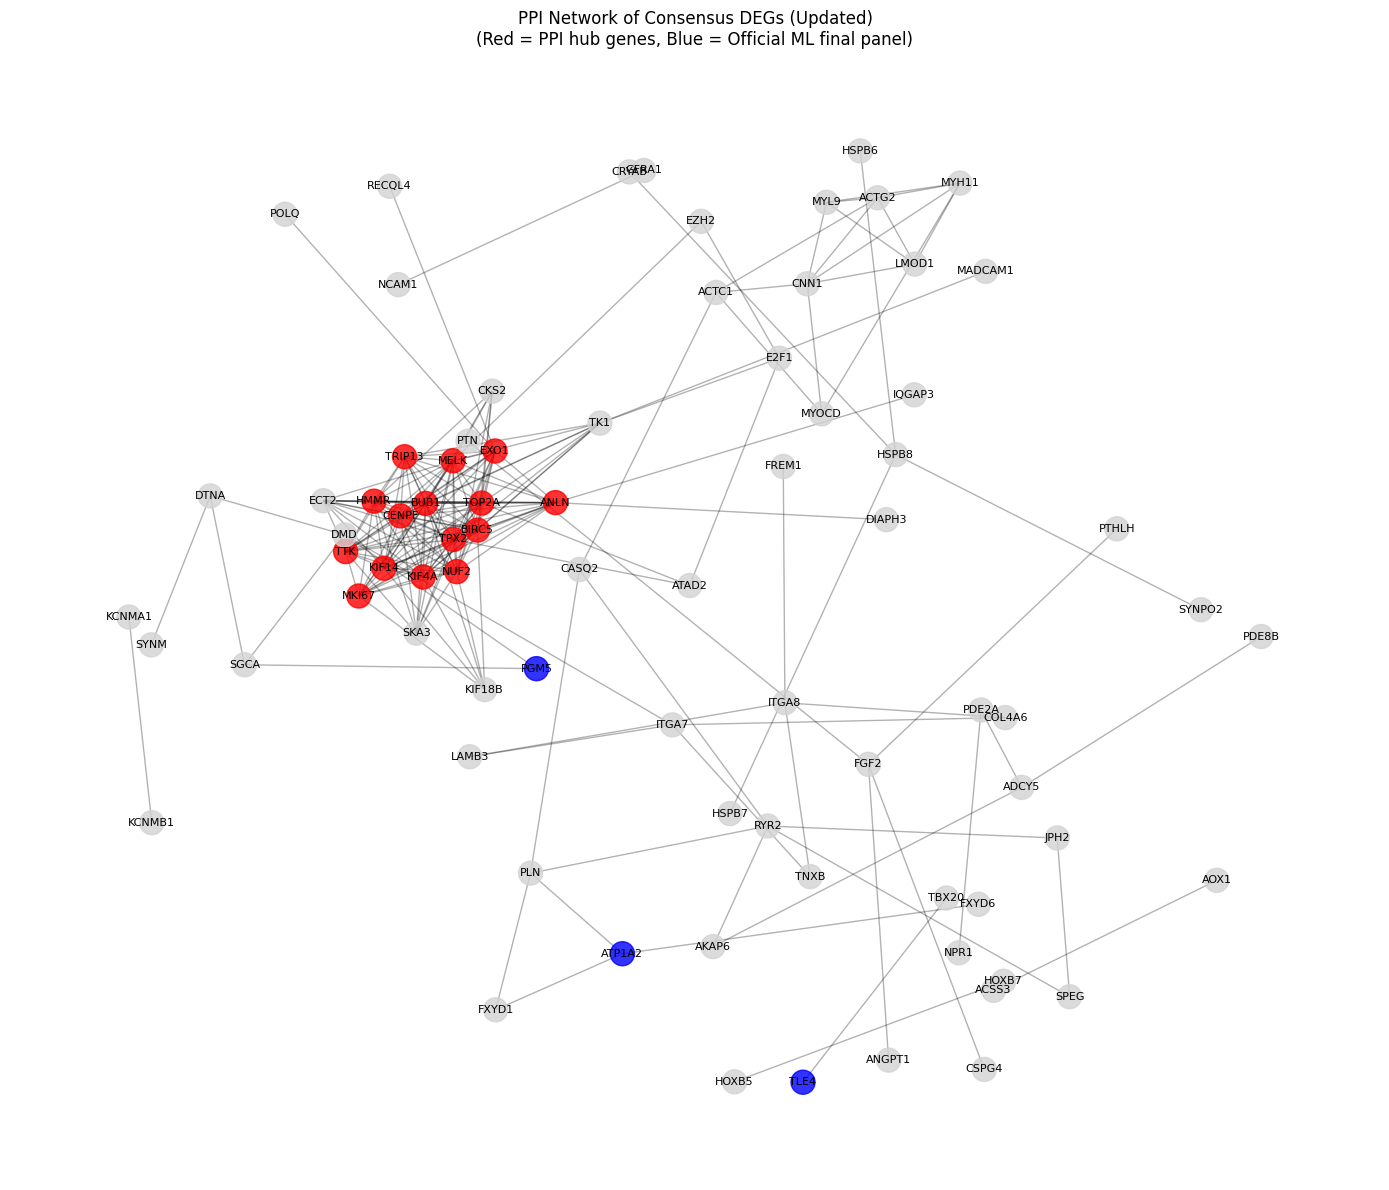

Final panel genes found in the PPI network: {'ATP1A2', 'PGM5', 'TLE4'}
Final panel ∩ PPI hub genes: set()


In [ ]:
# ============================================================
# STAGE 10: PPI Network Figure with the NEW official 10-gene final_panel
# ============================================================
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, k=0.5, seed=42)

node_colors = []
for node in G.nodes():
    if node in hub_genes:
        node_colors.append('red')
    elif node in final_panel:   # official 10-gene panel: FHL1, ATP1A2, RCAN2, PGM5, HLF, LIFR, TLE4, ARHGEF26, CNTN1, DPT
        node_colors.append('blue')
    else:
        node_colors.append('lightgray')

plt.figure(figsize=(14, 12))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("PPI Network of Consensus DEGs (Updated)\n(Red = PPI hub genes, Blue = Official ML final panel)")
plt.axis('off')
plt.tight_layout()
plt.savefig('ppi_network_final.png', dpi=300, bbox_inches='tight')
plt.show()

# Quick overlap check
print("Final panel genes found in the PPI network:", set(final_panel) & set(G.nodes()))
print("Final panel ∩ PPI hub genes:", set(final_panel) & hub_genes)

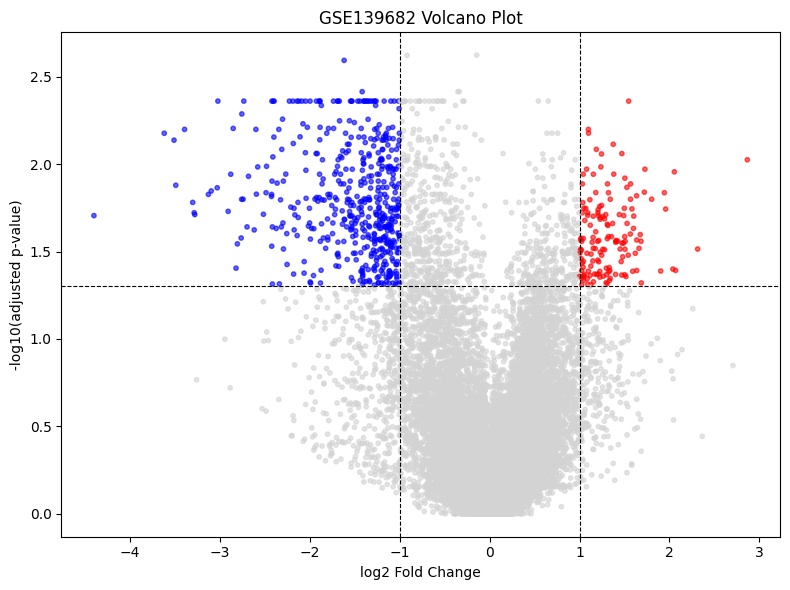

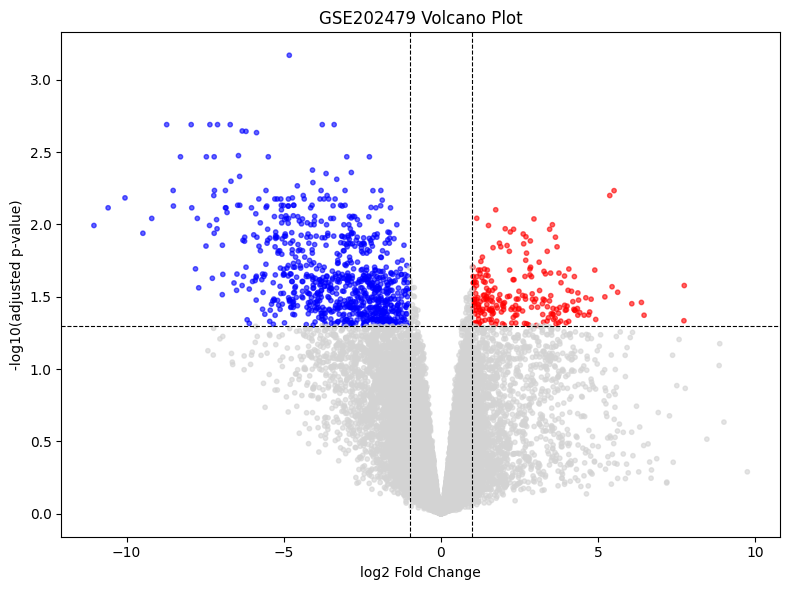

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_volcano(deg_df, title="Volcano Plot", logfc_thresh=1, padj_thresh=0.05):
    deg_df = deg_df.copy()
    deg_df['neg_log10_padj'] = -np.log10(deg_df['adj.P.Val'].replace(0, 1e-300))

    colors = []
    for _, row in deg_df.iterrows():
        if row['adj.P.Val'] < padj_thresh and row['logFC'] > logfc_thresh:
            colors.append('red')       # up-regulated
        elif row['adj.P.Val'] < padj_thresh and row['logFC'] < -logfc_thresh:
            colors.append('blue')      # down-regulated
        else:
            colors.append('lightgray') # not significant

    plt.figure(figsize=(8,6))
    plt.scatter(deg_df['logFC'], deg_df['neg_log10_padj'], c=colors, alpha=0.6, s=10)
    plt.axhline(-np.log10(padj_thresh), linestyle='--', color='black', linewidth=0.8)
    plt.axvline(logfc_thresh, linestyle='--', color='black', linewidth=0.8)
    plt.axvline(-logfc_thresh, linestyle='--', color='black', linewidth=0.8)
    plt.xlabel('log2 Fold Change')
    plt.ylabel('-log10(adjusted p-value)')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'volcano_{title.replace(" ","_")}.png', dpi=300)
    plt.show()

plot_volcano(deg_139682, title="GSE139682 Volcano Plot")
plot_volcano(deg_202479, title="GSE202479 Volcano Plot")

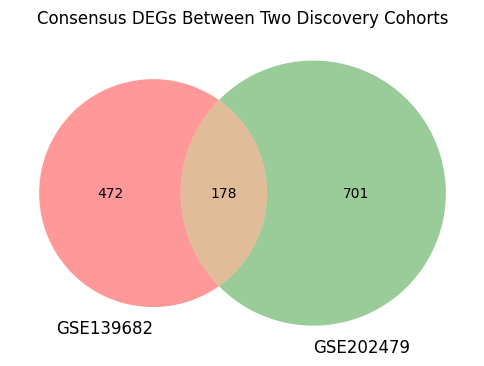

In [ ]:
!pip install matplotlib-venn --quiet
from matplotlib_venn import venn2

plt.figure(figsize=(6,6))
venn2([sig_139682_genes, sig_202479_genes], set_labels=('GSE139682', 'GSE202479'))
plt.title('Consensus DEGs Between Two Discovery Cohorts')
plt.savefig('venn_diagram.png', dpi=300)
plt.show()

--- Honest, leakage-free AUC per model (per-fold, fresh feature selection) ---
Random Forest: AUC = 0.978 +/- 0.044 | folds: [1.    1.    0.889 1.    1.   ]
SVM: AUC = 0.978 +/- 0.044 | folds: [1.    1.    0.889 1.    1.   ]
Logistic Regression: AUC = 0.978 +/- 0.044 | folds: [1.    1.    0.889 1.    1.   ]


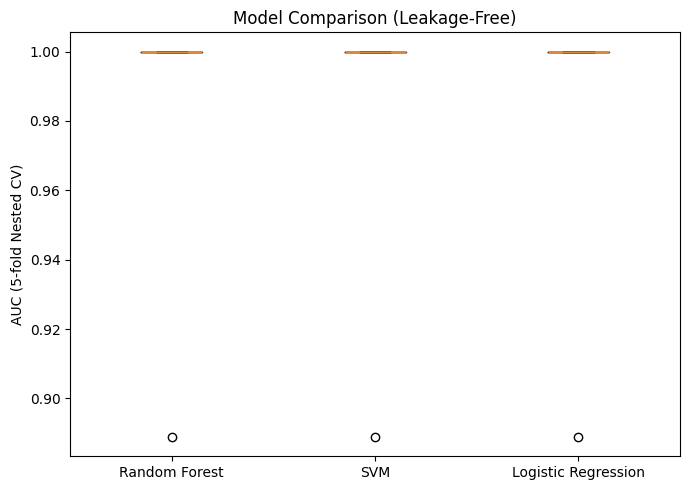

In [ ]:
# ============================================================
# HONEST Model Comparison: feature selection happens fresh
# inside each fold (same logic as Stage 4), for every model
# ============================================================
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

model_results = {name: [] for name in models}

for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Feature selection using ONLY this fold's training data (no leakage)
    rf_select = RandomForestClassifier(n_estimators=300, random_state=42)
    rf_select.fit(X_train, y_train)
    importance = pd.Series(rf_select.feature_importances_, index=gene_names)
    top_genes = importance.sort_values(ascending=False).head(TOP_N).index.tolist()
    gene_idx = [gene_names.index(g) for g in top_genes]

    for name, model in models.items():
        model.fit(X_train[:, gene_idx], y_train)
        prob = model.predict_proba(X_test[:, gene_idx])[:, 1]
        model_results[name].append(roc_auc_score(y_test, prob))

print("--- Honest, leakage-free AUC per model (per-fold, fresh feature selection) ---")
for name, scores in model_results.items():
    print(f"{name}: AUC = {np.mean(scores):.3f} +/- {np.std(scores):.3f} | folds: {np.round(scores,3)}")

plt.figure(figsize=(7,5))
plt.boxplot(model_results.values(), tick_labels=model_results.keys())   # 'tick_labels' avoids the deprecation warning
plt.ylabel('AUC (5-fold Nested CV)')
plt.title('Model Comparison (Leakage-Free)')
plt.tight_layout()
plt.savefig('model_comparison_honest.png', dpi=300)
plt.show()

--- Honest, leakage-free performance (out-of-fold) ---
Random Forest: AUC = 0.985
SVM: AUC = 0.995
Logistic Regression: AUC = 0.995


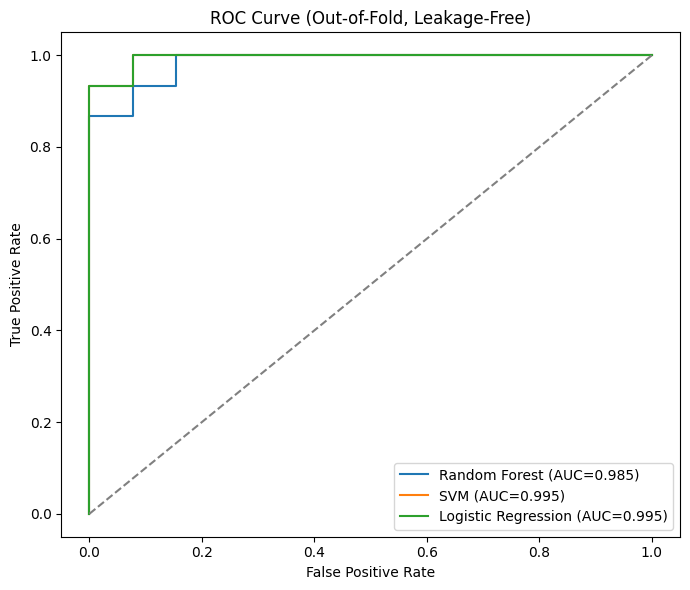

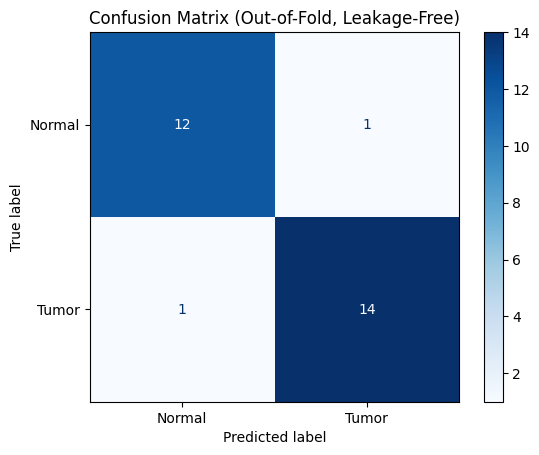

In [ ]:
# ============================================================
# CORRECTED: honest Model Comparison + ROC + Confusion Matrix
# using the ORIGINAL leakage-free nested-CV loop
# (feature selection happens fresh inside each fold, exactly like Stage 4)
# ============================================================
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Store out-of-fold true labels and predicted probabilities for each model
oof_true = []
oof_prob = {name: [] for name in models}
oof_pred = {name: [] for name in models}

for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Feature selection using ONLY this fold's training data (same as Stage 4)
    rf_select = RandomForestClassifier(n_estimators=300, random_state=42)
    rf_select.fit(X_train, y_train)
    importance = pd.Series(rf_select.feature_importances_, index=gene_names)
    top_genes = importance.sort_values(ascending=False).head(TOP_N).index.tolist()
    gene_idx = [gene_names.index(g) for g in top_genes]

    oof_true.extend(y_test)
    for name, model in models.items():
        model.fit(X_train[:, gene_idx], y_train)
        prob = model.predict_proba(X_test[:, gene_idx])[:, 1]
        pred = model.predict(X_test[:, gene_idx])
        oof_prob[name].extend(prob)
        oof_pred[name].extend(pred)

# ---- Honest AUC per model (from out-of-fold predictions) ----
print("--- Honest, leakage-free performance (out-of-fold) ---")
for name in models:
    auc = roc_auc_score(oof_true, oof_prob[name])
    print(f"{name}: AUC = {auc:.3f}")

# ---- ROC curve (honest version) ----
plt.figure(figsize=(7,6))
for name in models:
    fpr, tpr, _ = roc_curve(oof_true, oof_prob[name])
    auc_score = roc_auc_score(oof_true, oof_prob[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Out-of-Fold, Leakage-Free)')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_honest.png', dpi=300)
plt.show()

# ---- Confusion matrix (honest version, Random Forest as primary model) ----
cm = confusion_matrix(oof_true, oof_pred['Random Forest'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Tumor'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Out-of-Fold, Leakage-Free)')
plt.savefig('confusion_matrix_honest.png', dpi=300)
plt.show()

In [ ]:
# ============================================================
# Additional statistical evidence: Accuracy, Precision, Recall,
# F1-score, Specificity, and MCC -- using the same honest
# out-of-fold predictions (no new leakage introduced)
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, matthews_corrcoef, classification_report)

print("="*65)
print(f"{'Model':<20}{'Accuracy':<10}{'Precision':<11}{'Recall':<9}{'F1':<8}{'MCC':<8}")
print("="*65)

metrics_summary = {}
for name in models:
    acc = accuracy_score(oof_true, oof_pred[name])
    prec = precision_score(oof_true, oof_pred[name])
    rec = recall_score(oof_true, oof_pred[name])   # this is Sensitivity (tumor detection rate)
    f1 = f1_score(oof_true, oof_pred[name])
    mcc = matthews_corrcoef(oof_true, oof_pred[name])

    metrics_summary[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'MCC': mcc}
    print(f"{name:<20}{acc:<10.3f}{prec:<11.3f}{rec:<9.3f}{f1:<8.3f}{mcc:<8.3f}")

print("="*65)

# ---- Specificity separately (true negative rate -- not built into sklearn directly) ----
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

print("\nSpecificity (Normal detection rate):")
for name in models:
    spec = specificity_score(oof_true, oof_pred[name])
    print(f"{name}: {spec:.3f}")

# ---- Full classification report (per-class breakdown, standard in papers) ----
print("\n--- Detailed Classification Report (Random Forest) ---")
print(classification_report(oof_true, oof_pred['Random Forest'], target_names=['Normal', 'Tumor']))

Model               Accuracy  Precision  Recall   F1      MCC     
Random Forest       0.929     0.933      0.933    0.933   0.856   
SVM                 0.964     1.000      0.933    0.966   0.931   
Logistic Regression 0.929     0.933      0.933    0.933   0.856   

Specificity (Normal detection rate):
Random Forest: 0.923
SVM: 1.000
Logistic Regression: 0.923

--- Detailed Classification Report (Random Forest) ---
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92        13
       Tumor       0.93      0.93      0.93        15

    accuracy                           0.93        28
   macro avg       0.93      0.93      0.93        28
weighted avg       0.93      0.93      0.93        28



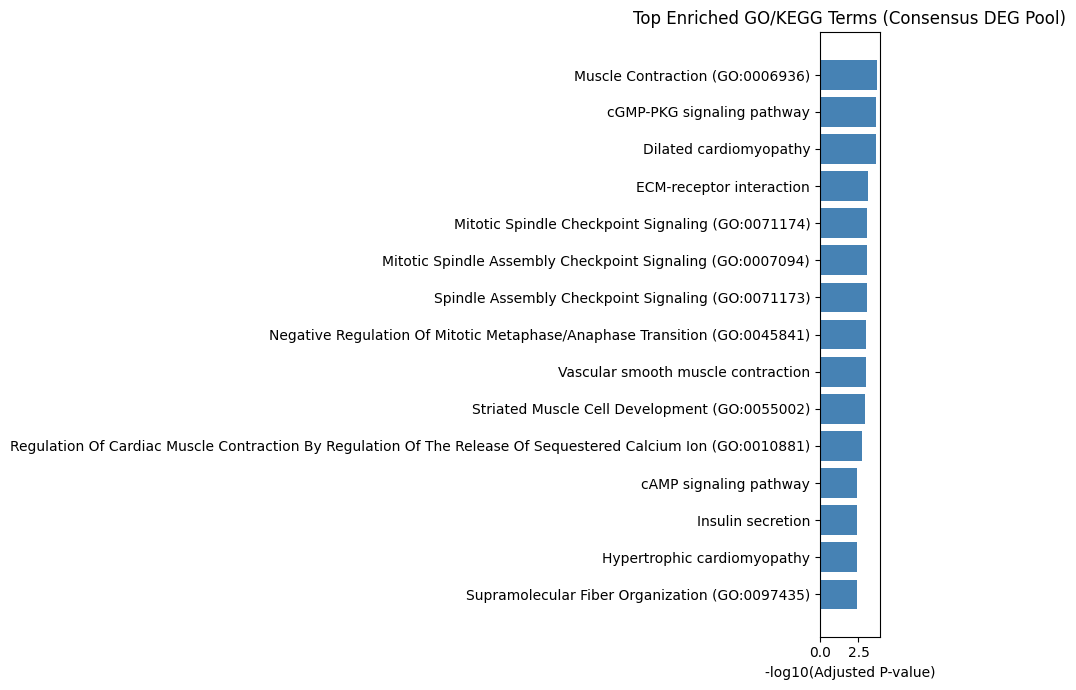

In [ ]:
# ============================================================
# GO/KEGG enrichment bar plot (standard figure in almost every paper)
# ============================================================
import matplotlib.pyplot as plt

top_terms = results_full[results_full['Overlap_Count'] >= 3].head(15).copy()
top_terms['neg_log10_p'] = -np.log10(top_terms['Adjusted P-value'])
top_terms = top_terms.sort_values('neg_log10_p')

plt.figure(figsize=(9,7))
plt.barh(top_terms['Term'], top_terms['neg_log10_p'], color='steelblue')
plt.xlabel('-log10(Adjusted P-value)')
plt.title('Top Enriched GO/KEGG Terms (Consensus DEG Pool)')
plt.tight_layout()
plt.savefig('go_kegg_barplot.png', dpi=300)
plt.show()

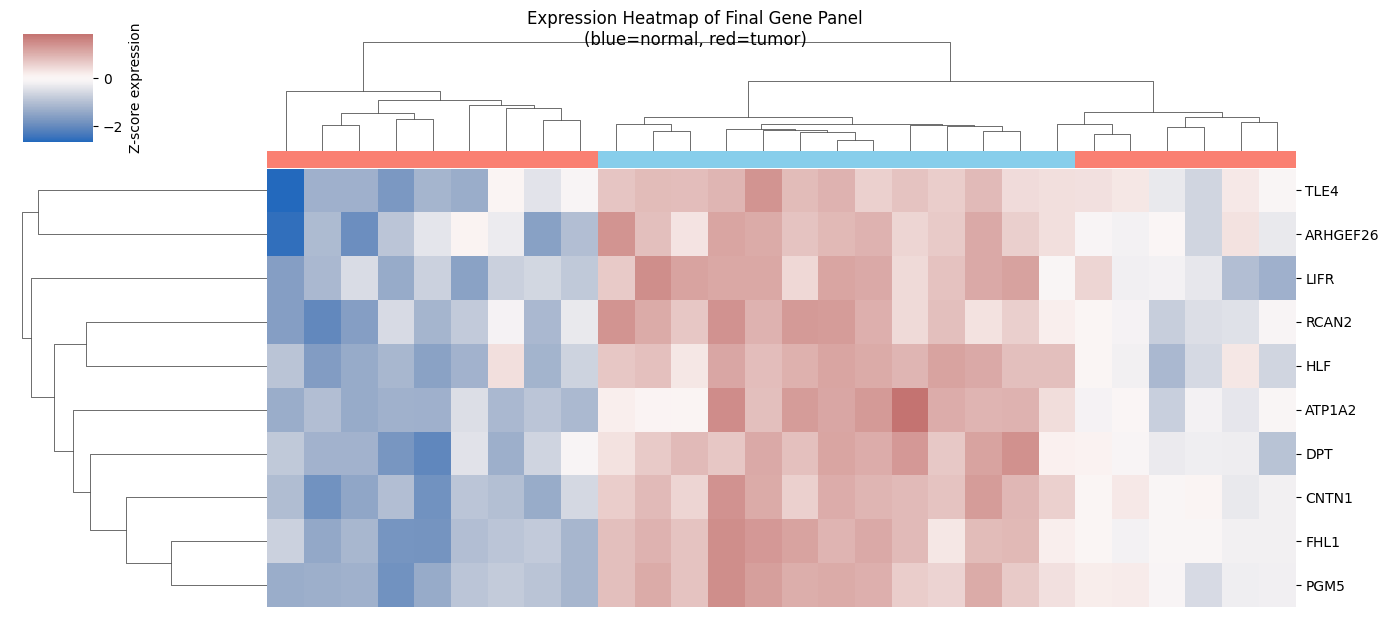

In [ ]:
# ============================================================
# Heatmap of final panel gene expression across all discovery samples
# ============================================================
import seaborn as sns

heatmap_data = discovery_expr[final_panel].T   # genes x samples
heatmap_data.columns = discovery_expr.index

# Color labels: normal=blue, tumor=red (for column color bar)
label_colors = ['skyblue' if l=='normal' else 'salmon' for l in discovery_labels]

g = sns.clustermap(heatmap_data, cmap='vlag', center=0,
                    col_colors=label_colors,
                    figsize=(14,6), xticklabels=False,
                    cbar_kws={'label': 'Z-score expression'})
g.fig.suptitle('Expression Heatmap of Final Gene Panel\n(blue=normal, red=tumor)', y=1.02)
plt.savefig('gene_panel_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

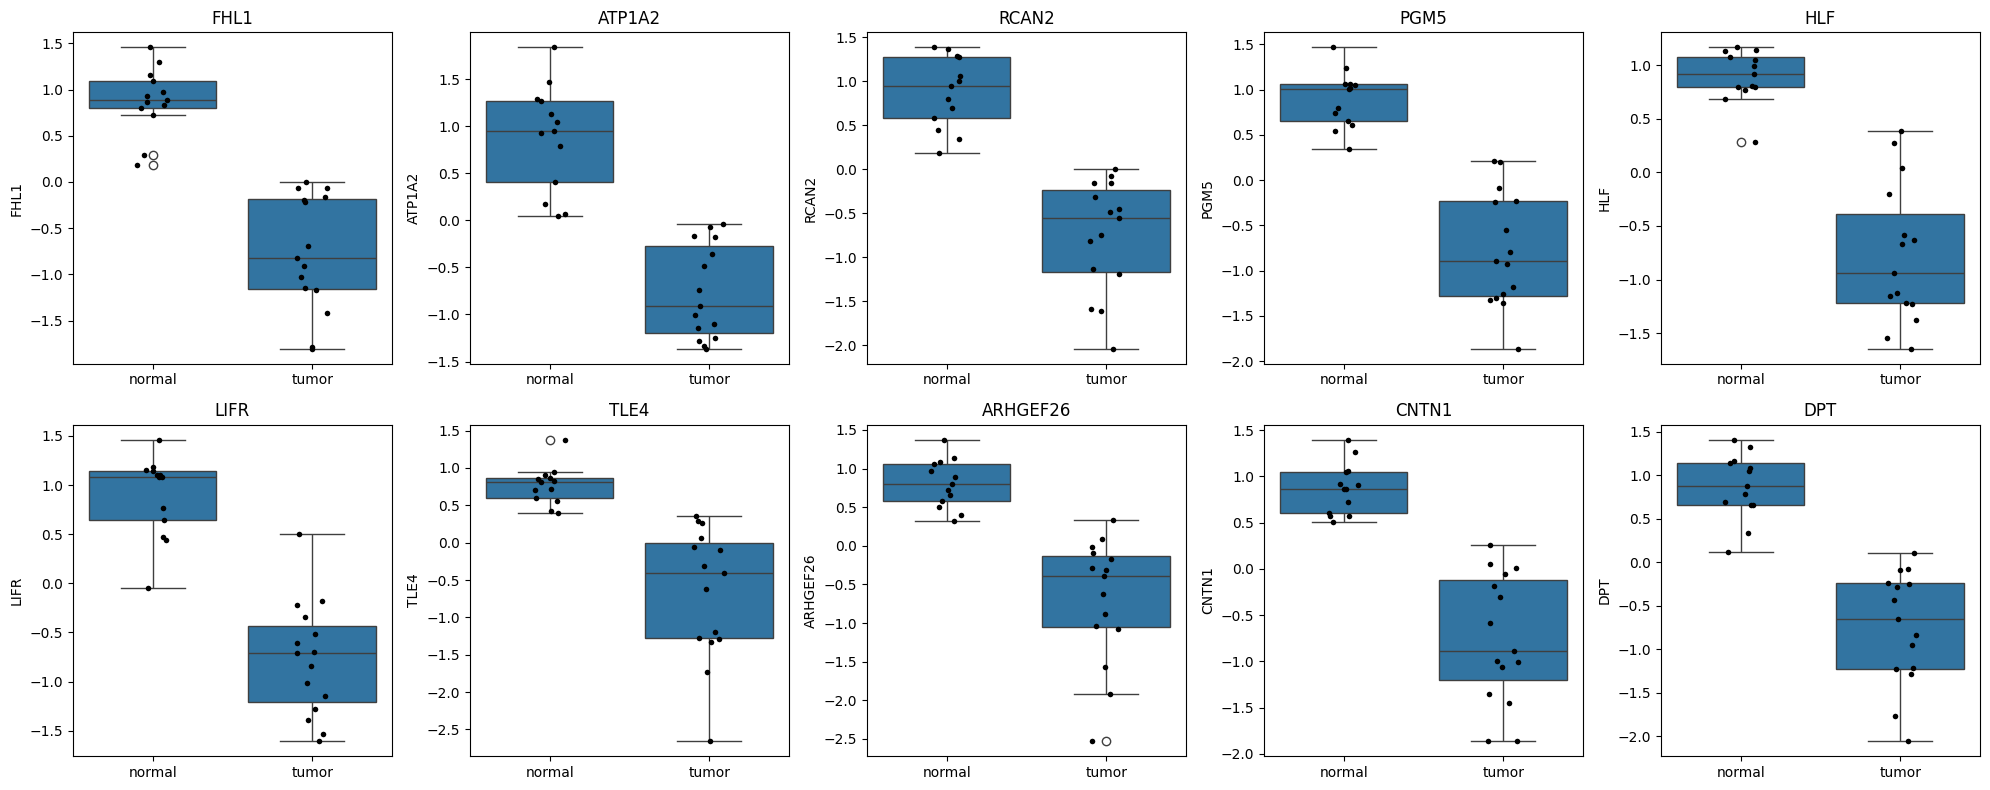

In [ ]:
# ============================================================
# Boxplot for each final panel gene: Normal vs Tumor (discovery cohort)
# ============================================================
box_df = discovery_expr[final_panel].copy()
box_df['label'] = discovery_labels

fig, axes = plt.subplots(2, 5, figsize=(20,8))
axes = axes.flatten()
for i, gene in enumerate(final_panel):
    sns.boxplot(data=box_df, x='label', y=gene, ax=axes[i], order=['normal','tumor'])
    sns.stripplot(data=box_df, x='label', y=gene, ax=axes[i], color='black', size=4, order=['normal','tumor'])
    axes[i].set_title(gene)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('gene_panel_boxplots.png', dpi=300)
plt.show()

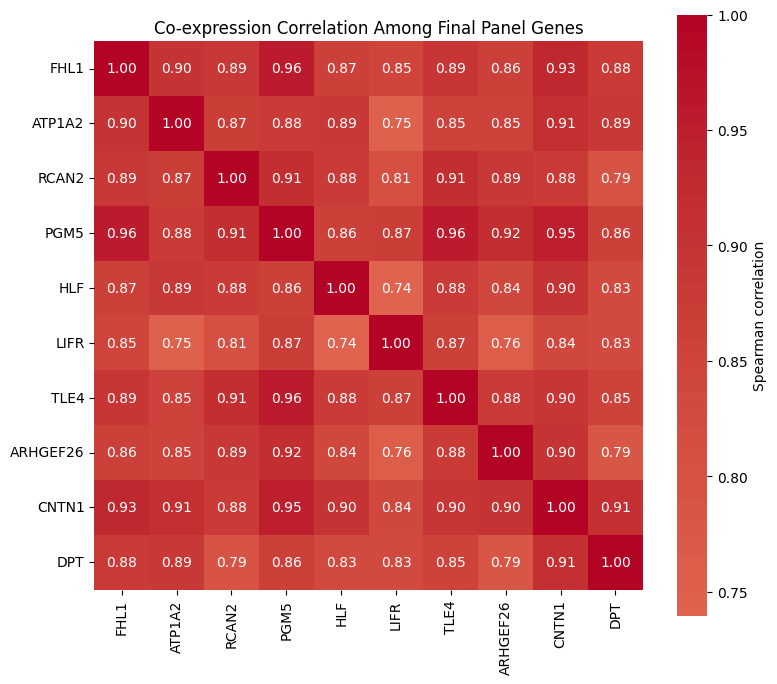

In [ ]:
# ============================================================
# Correlation heatmap among final panel genes (co-expression pattern)
# ============================================================
corr_matrix = discovery_expr[final_panel].corr(method='spearman')

plt.figure(figsize=(8,7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Spearman correlation'})
plt.title('Co-expression Correlation Among Final Panel Genes')
plt.tight_layout()
plt.savefig('gene_correlation_heatmap.png', dpi=300)
plt.show()